# Train/Test Splitting

To test our models, we need to see how they do on unseen instances. To achieve this, we divide our data into a training set and a testing set. We only train our data on the training set, that way we can assess how well it does on the testing set.

How should we split the dataset?

## Method One: Holdout method
- "hold out" some instances for testing
    - Train on the remaining instances
- Typically use a standard "split" or percentage holdout
    - 2:1 split: holdout 1/3 for testing, train on remaining 2/3
    - 25% holdout: holdout 25% for testing, train on remaining 75%
        - Sci-kit learn default for train_test_split()


In [182]:
import pandas as pd
df = pd.read_csv("shirt_sizes_long.csv")
X = df.drop(["t-shirt size"], axis="columns")
y = df["t-shirt size"]
print(X)
print(y)

    height(cm)  weight(kg)
0          158          58
1          158          59
2          158          63
3          160          59
4          160          60
5          163          60
6          163          61
7          160          64
8          163          64
9          165          61
10         165          62
11         165          65
12         168          62
13         168          63
14         168          66
15         170          63
16         170          64
17         170          68
0     M
1     M
2     M
3     M
4     M
5     M
6     M
7     L
8     L
9     L
10    L
11    L
12    L
13    L
14    L
15    L
16    L
17    L
Name: t-shirt size, dtype: object


In [183]:
from sklearn.model_selection import train_test_split

# shuffles by default
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, stratify=y)
print(X_train)
print(y_train)

    height(cm)  weight(kg)
6          163          61
16         170          64
0          158          58
2          158          63
12         168          62
8          163          64
15         170          63
7          160          64
10         165          62
17         170          68
9          165          61
3          160          59
11         165          65
5          163          60
6     M
16    L
0     M
2     M
12    L
8     L
15    L
7     L
10    L
17    L
9     L
3     M
11    L
5     M
Name: t-shirt size, dtype: object


In [184]:
print(X_test)
print(y_test)

    height(cm)  weight(kg)
4          160          60
1          158          59
13         168          63
14         168          66
4     M
1     M
13    L
14    L
Name: t-shirt size, dtype: object


In [185]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train) # fitting it will determine the minimum and maximum values for each feature

X_test = scaler.transform(X_test)

In [186]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn_clf.fit(X_train, y_train)
y_predicted = knn_clf.predict(X_test)
print(y_predicted)

['M' 'M' 'L' 'L']


In [187]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_predicted)
print(f"accuracy: {acc}")

# Other way to get accuracy
acc = knn_clf.score(X_test, y_test)
print("accuracy:", acc)

accuracy: 1.0
accuracy: 1.0


In [188]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_predicted)
print(cm)

[[2 0]
 [0 2]]


tree accuracy: 1.0
[[2 0]
 [0 2]]


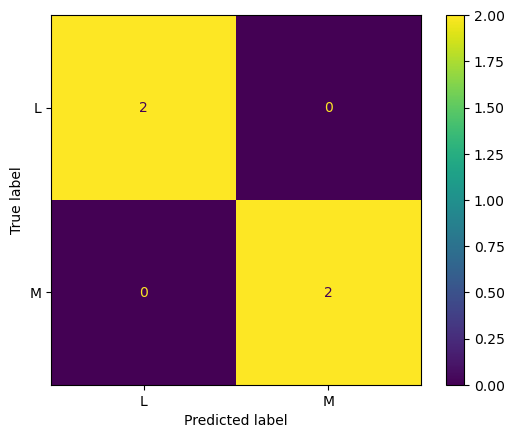

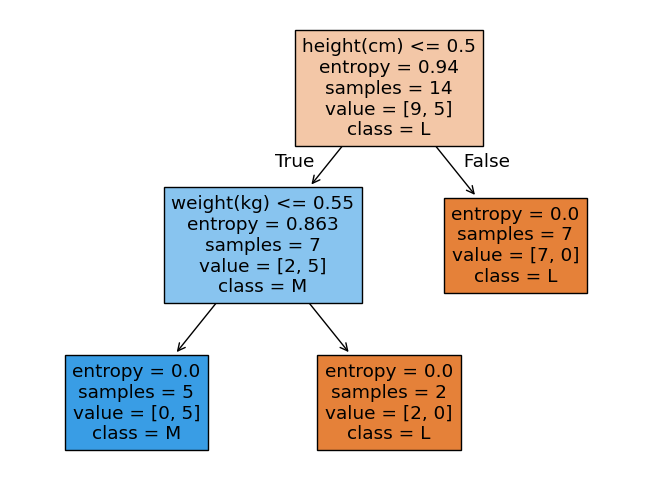

In [189]:
# Can a decision tree do better? 
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

tree_clf = DecisionTreeClassifier(criterion="entropy")

# task: take it from here!

tree_clf.fit(X_train, y_train)
y_predicted = tree_clf.predict(X_test)
tree_acc = accuracy_score(y_test, y_predicted)
print(f"tree accuracy: {tree_acc}")
tree_cm = confusion_matrix(y_test, y_predicted)
disp = ConfusionMatrixDisplay(confusion_matrix=tree_cm, display_labels=tree_clf.classes_)
disp.plot()
print(tree_cm)



plt.figure(layout="constrained")
plot_tree(tree_clf, filled=True, feature_names=X.columns, class_names = tree_clf.classes_)
plt.show()

## k Fold Cross Validation
- With cross validation, every instance is in hte test set exactly one time
- Basic Alg: divide the dataset into folds
    - For each fold
        - Test on the fold
        - train on the remaining folds
- Accuracy is total correctly predicted over all the folds divided by the total number of instances
- This gives you a baseline idea of how well your model is likely to perform on unseen data.
- After using cross validation to evaluate and compare models, train your final model on the full dataset.

In [ ]:
from sklearn.model_selection import cross_val_score, cross_val_predict
import numpy as np
from sklearn.pipeline import make_pipeline




# do 5 fold cross validation for both the knn and decision tree classifiers

models = [
    ("tree_clf", DecisionTreeClassifier(criterion="entropy")),
    ("knn_3", make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=3, metric="euclidean"))),
    ("knn_5", make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=5, metric="euclidean"))),
    ("knn_7", make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=7, metric="euclidean")))
]


for model in models:
    print(model[0])

    accuracies = cross_val_score(model[1], X, y, cv=5)
    print(accuracies, np.mean(accuracies))
    
    # better way to calculate accuracy
    
    y_predicted = cross_val_predict(model[1], X, y, cv=5)
    acc = accuracy_score(y, y_predicted)
    print(acc)
    print(confusion_matrix(y, y_predicted))


tree_clf
[0.66666667 1.         0.66666667] 0.7777777777777777
0.7777777777777778
[[10  1]
 [ 3  4]]
knn_3


[0.66666667 0.83333333 0.83333333] 0.7777777777777778
0.7777777777777778
[[8 3]
 [1 6]]
knn_5
[0.83333333 1.         0.83333333] 0.888888888888889
0.8888888888888888
[[10  1]
 [ 1  6]]
knn_7
[0.83333333 1.         0.66666667] 0.8333333333333334
0.8333333333333334
[[10  1]
 [ 2  5]]
